## 📍 Sub-Proyek 1: Cross-City Price Benchmarking & Purchasing Power Parity (PPP) Normalization

### 🎯 Tujuan Analisis:
1. **Universal Food Basket Identification**: Mengidentifikasi menu identik lintas benua (contoh: *Margherita Pizza, Cheeseburger, Cappuccino, Chicken Biryani, Pad Thai*).
2. **Currency Standardization**: Mengonversi harga lokal ke basis acuan tunggal (**USD**).
3. **Purchasing Power Parity (PPP) Adjustment**: Menghitung harga riil yang dinormalisasi dengan indeks biaya hidup (*Cost of Living / PPP Factor*) untuk mengukur tingkat keterjangkauan (*affordability*) lokal.
4. **Market Heatmap & Ranking**: Memetakan disparitas harga global dan menyusun peringkat kota dari yang paling terjangkau hingga paling premium.

In [25]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Warning & Display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup environment & dependencies berhasil.")

✅ Setup environment & dependencies berhasil.


In [26]:
# ==============================================================================
# 2. INGESTION DATASET & RELATIONAL LINKING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"  # Sesuaikan path jika file berada di direktori khusus

def load_and_merge_datasets(path=DATASET_PATH):
    print("📂 Memuat tabel-tabel data relasional...")
    
    # 1. Baca tabel primer yang dibutuhkan untuk Benchmarking
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    menus_df = pd.read_csv(os.path.join(path, "menus.csv"))
    
    print(f" ✔ cities.csv          : {cities_df.shape[0]:,} baris | {cities_df.shape[1]} kolom")
    print(f" ✔ countries.csv       : {countries_df.shape[0]:,} baris | {countries_df.shape[1]} kolom")
    print(f" ✔ restaurants.csv     : {restaurants_df.shape[0]:,} baris | {restaurants_df.shape[1]} kolom")
    print(f" ✔ menus.csv           : {menus_df.shape[0]:,} baris | {menus_df.shape[1]} kolom")
    
    # --------------------------------------------------------------------------
    # Relational Join Architecture:
    # menus -> restaurants (on Restaurant_ID)
    #       -> cities (on City, Country)
    #       -> countries (on Country)
    # --------------------------------------------------------------------------
    
    # Gabungkan Restoran dengan Indikator Kota (Population, Income, Cost of Living)
    rest_city = restaurants_df.merge(
        cities_df,
        on=['City', 'Country'],
        how='left',
        suffixes=('', '_city_tab')
    )
    
    # Gabungkan dengan Metadata Negara (Region, Income_group, ISO_code)
    rest_geo = rest_city.merge(
        countries_df[['Country', 'Region', 'Income_group', 'ISO_code']],
        on='Country',
        how='left'
    )
    
    # Gabungkan Menu dengan Entitas Restoran & Geografis
    master_df = menus_df.merge(
        rest_geo,
        on='Restaurant_ID',
        how='inner',
        suffixes=('_menu', '_rest')
    )
    
    print(f"\n📊 Master Linked Table terbentuk: {master_df.shape[0]:,} baris menu terhubung.")
    return master_df

master_df = load_and_merge_datasets()

📂 Memuat tabel-tabel data relasional...
 ✔ cities.csv          : 10 baris | 9 kolom
 ✔ countries.csv       : 5 baris | 6 kolom
 ✔ restaurants.csv     : 5,000 baris | 17 kolom
 ✔ menus.csv           : 62,417 baris | 15 kolom

📊 Master Linked Table terbentuk: 62,417 baris menu terhubung.


In [27]:
# ==============================================================================
# INSPEKSI NILAI UNIK (UNIQUE VALUES) & PROFILING SEMUA DATASET
# ==============================================================================
import os
import pandas as pd

# Daftar semua file CSV dalam dataset
DATASET_FILES = [
    "cities.csv",
    "city_statistics.csv",
    "countries.csv",
    "cuisines.csv",
    "delivery_metrics.csv",
    "menus.csv",
    "nutrition.csv",
    "price_history.csv",
    "restaurant_features.csv",
    "restaurant_statistics.csv",
    "restaurants.csv"
]

DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"  # Sesuaikan path jika file berada di folder terpisah

def inspect_dataset_unique_values(files, path=DATASET_PATH, max_display_uniques=10):
    """
    Menampilkan jumlah nilai unik, persentase keunikan, jumlah null,
    serta sampel/seluruh nilai unik untuk setiap kolom pada semua tabel.
    """
    summary_records = []

    for file_name in files:
        file_path = os.path.join(path, file_name)
        
        if not os.path.exists(file_path):
            print(f"⚠️ File tidak ditemukan: {file_path}")
            continue

        df = pd.read_csv(file_path)
        total_rows = len(df)
        
        print("=" * 90)
        print(f"📁 DATASET: {file_name} | Total Baris: {total_rows:,} | Total Kolom: {df.shape[1]}")
        print("=" * 90)

        for col in df.columns:
            n_unique = df[col].nunique(dropna=False)
            n_null = df[col].isnull().sum()
            pct_null = (n_null / total_rows) * 100 if total_rows > 0 else 0
            unique_vals = df[col].dropna().unique()

            # Format tampilan nilai unik
            if len(unique_vals) <= max_display_uniques:
                uniques_preview = list(unique_vals)
            else:
                uniques_preview = f"{list(unique_vals[:5])} ... (+ {len(unique_vals) - 5} lainnya)"

            print(f"🔹 Kolom: {col:<26} | Tipe: {str(df[col].dtype):<8} | Unik: {n_unique:<6} | Null: {n_null} ({pct_null:.1f}%)")
            print(f"   Contoh Nilai: {uniques_preview}\n")

            summary_records.append({
                "Dataset": file_name,
                "Column": col,
                "Data_Type": str(df[col].dtype),
                "Total_Rows": total_rows,
                "Unique_Count": n_unique,
                "Unique_Pct": round((n_unique / total_rows) * 100, 2) if total_rows > 0 else 0,
                "Null_Count": n_null,
                "Null_Pct": round(pct_null, 2),
                "Unique_Sample": str(uniques_preview)
            })

    # Buat ringkasan tabular lengkap
    summary_df = pd.DataFrame(summary_records)
    return summary_df

# Eksekusi inspeksi
unique_summary_df = inspect_dataset_unique_values(DATASET_FILES)

📁 DATASET: cities.csv | Total Baris: 10 | Total Kolom: 9
🔹 Kolom: City                       | Tipe: object   | Unik: 10     | Null: 0 (0.0%)
   Contoh Nilai: ['New York', 'Los Angeles', 'London', 'Manchester', 'Mumbai', 'Delhi', 'Tokyo', 'Osaka', 'Sao Paulo', 'Rio de Janeiro']

🔹 Kolom: Country                    | Tipe: object   | Unik: 5      | Null: 0 (0.0%)
   Contoh Nilai: ['USA', 'United Kingdom', 'India', 'Japan', 'Brazil']

🔹 Kolom: Population                 | Tipe: int64    | Unik: 10     | Null: 0 (0.0%)
   Contoh Nilai: [np.int64(8419000), np.int64(3898000), np.int64(8982000), np.int64(552000), np.int64(12442000), np.int64(16787000), np.int64(13929000), np.int64(2691000), np.int64(12325000), np.int64(6747000)]

🔹 Kolom: Area_km2                   | Tipe: float64  | Unik: 10     | Null: 0 (0.0%)
   Contoh Nilai: [np.float64(783.8), np.float64(1302.0), np.float64(1572.0), np.float64(115.0), np.float64(603.0), np.float64(1484.0), np.float64(2194.0), np.float64(223.0), np.floa

In [28]:
# ==============================================================================
# 3. FX CONVERSION & PPP NORMALIZATION ENGINE
# ==============================================================================

# A. Standardisasi Nilai Tukar (FX to USD) untuk 5 Currency Unik di Dataset
# ['USD', 'GBP', 'JPY', 'BRL', 'INR']
fx_rates = {
    'USD': 1.0000,
    'GBP': 1.2800,   # British Pound
    'BRL': 0.1800,   # Brazilian Real (~5.55 BRL/USD)
    'INR': 0.0120,   # Indian Rupee (~83.3 INR/USD)
    'JPY': 0.0065    # Japanese Yen (~153.8 JPY/USD)
}

# Terapkan konversi FX ke basis nominal USD
master_df['FX_to_USD'] = master_df['Currency'].map(fx_rates).fillna(1.0)
master_df['Price_USD_Nominal'] = master_df['Price'] * master_df['FX_to_USD']

# B. Formula Normalisasi Daya Beli (PPP / Purchasing Power Parity)
# Menggunakan Cost_of_living_index dari cities.csv (NYC = 100 sebagai anchor)
# PPP_Price = (Price_USD_Nominal / Cost_of_living_index) * 100
master_df['Cost_of_living_index'] = master_df['Cost_of_living_index'].astype(float)
master_df['Price_PPP_Adjusted'] = (master_df['Price_USD_Nominal'] / master_df['Cost_of_living_index']) * 100

# C. Hitung Affordability Ratio (% dari Pendapatan Rata-Rata Harian)
# Daily Income = Average_income / 365
master_df['Daily_Income_USD'] = master_df['Average_income'] / 365.0
master_df['Price_to_Daily_Income_Pct'] = (master_df['Price_USD_Nominal'] / master_df['Daily_Income_USD']) * 100

# Validasi distribusi per kategori makanan dan kota
print("✅ Konversi FX dan normalisasi PPP berhasil dihitung.")
print("\n📊 Rata-rata Harga Nominal (USD) per Kategori Makanan:")
display(master_df.groupby('Food_category')[['Price_USD_Nominal', 'Price_PPP_Adjusted']].mean())

✅ Konversi FX dan normalisasi PPP berhasil dihitung.

📊 Rata-rata Harga Nominal (USD) per Kategori Makanan:


,Price_USD_Nominal,Price_PPP_Adjusted
Food_category,,
Beverage,28.16,33.76
Dessert,28.30,33.79
Main,27.86,33.31
Starter,27.78,33.29


In [29]:
# ==============================================================================
# 4. BENCHMARKING ITEM IDENTIK & FOOD CATEGORY
# ==============================================================================

# A. Identifikasi Item Identik yang Tersebar di Semua 10 Kota
# Menemukan Item_name dengan frekuensi tertinggi di seluruh kota
top_identical_items = (
    master_df.groupby('Item_name')['City']
    .nunique()
    .loc[lambda x: x == 10]
    .index.tolist()
)

print(f"🎯 Ditemukan {len(top_identical_items)} item identik yang tersedia di seluruh 10 kota.")

# Ambil sampel 5 item identik representatif lintas kategori (Main, Starter, Beverage, Dessert)
sample_basket_items = master_df[master_df['Item_name'].isin(top_identical_items)].drop_duplicates('Item_name').head(5)['Item_name'].tolist()
print("Anchor Basket Items terpilih:", sample_basket_items)

# B. Pivot Table 1: Rata-Rata Harga Nominal per Food Category (USD)
pivot_category_nominal = master_df.pivot_table(
    index='City',
    columns='Food_category',
    values='Price_USD_Nominal',
    aggfunc='mean'
)

# C. Pivot Table 2: Rata-Rata Harga PPP-Adjusted per Food Category (USD)
pivot_category_ppp = master_df.pivot_table(
    index='City',
    columns='Food_category',
    values='Price_PPP_Adjusted',
    aggfunc='mean'
)

# D. Pivot Table 3: Item Identik Tertentu Lintas Kota (Nominal vs PPP)
identical_basket_df = master_df[master_df['Item_name'].isin(sample_basket_items)]
pivot_items_nominal = identical_basket_df.pivot_table(
    index='City',
    columns='Item_name',
    values='Price_USD_Nominal',
    aggfunc='mean'
)
pivot_items_ppp = identical_basket_df.pivot_table(
    index='City',
    columns='Item_name',
    values='Price_PPP_Adjusted',
    aggfunc='mean'
)

print("\n💵 Pivot Table: Harga Nominal per Kategori Makanan (USD):")
display(pivot_category_nominal)

print("\n⚖️ Pivot Table: Harga PPP-Adjusted per Kategori Makanan (Beban Riil):")
display(pivot_category_ppp)

🎯 Ditemukan 80 item identik yang tersedia di seluruh 10 kota.
Anchor Basket Items terpilih: ['Main Item 0', 'Beverage Item 1', 'Starter Item 2', 'Main Item 3', 'Beverage Item 4']

💵 Pivot Table: Harga Nominal per Kategori Makanan (USD):


Food_category,Beverage,Dessert,Main,Starter
City,,,,
Delhi,0.69,0.70,0.68,0.69
London,72.75,70.36,71.24,70.37
Los Angeles,56.89,56.85,56.07,56.23
Manchester,71.89,69.33,69.47,70.49
Mumbai,0.69,0.68,0.69,0.70
New York,57.34,58.56,58.41,56.79
Osaka,0.37,0.36,0.36,0.36
Rio de Janeiro,9.70,9.89,9.86,9.59
Sao Paulo,9.88,9.94,10.18,9.89



⚖️ Pivot Table: Harga PPP-Adjusted per Kategori Makanan (Beban Riil):


Food_category,Beverage,Dessert,Main,Starter
City,,,,
Delhi,1.81,1.83,1.80,1.82
London,80.83,78.18,79.16,78.19
Los Angeles,59.89,59.85,59.02,59.19
Manchester,95.85,92.44,92.63,93.98
Mumbai,1.73,1.70,1.71,1.74
New York,57.34,58.56,58.41,56.79
Osaka,0.46,0.46,0.45,0.45
Rio de Janeiro,17.64,17.98,17.93,17.44
Sao Paulo,19.77,19.87,20.35,19.79


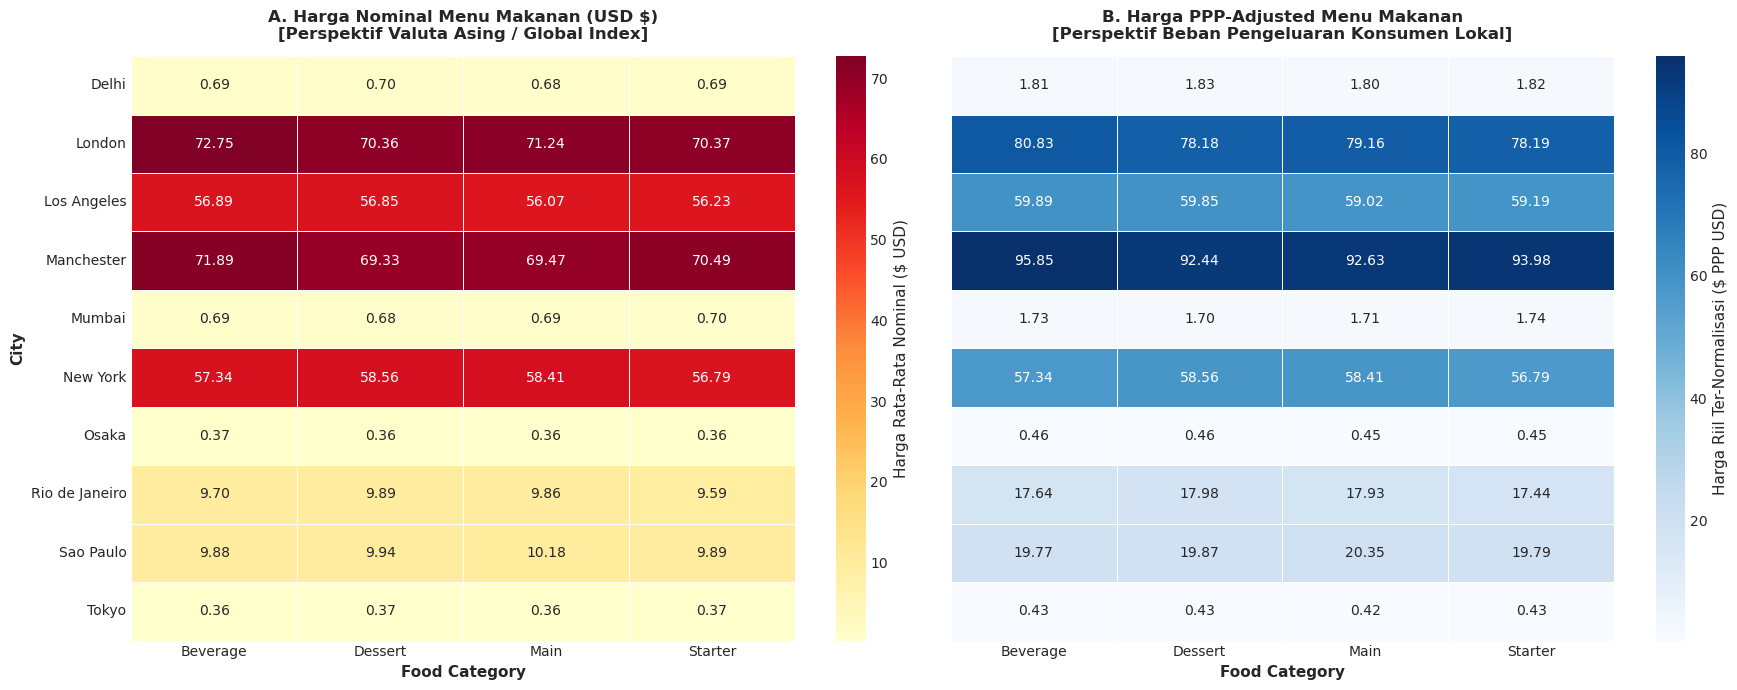

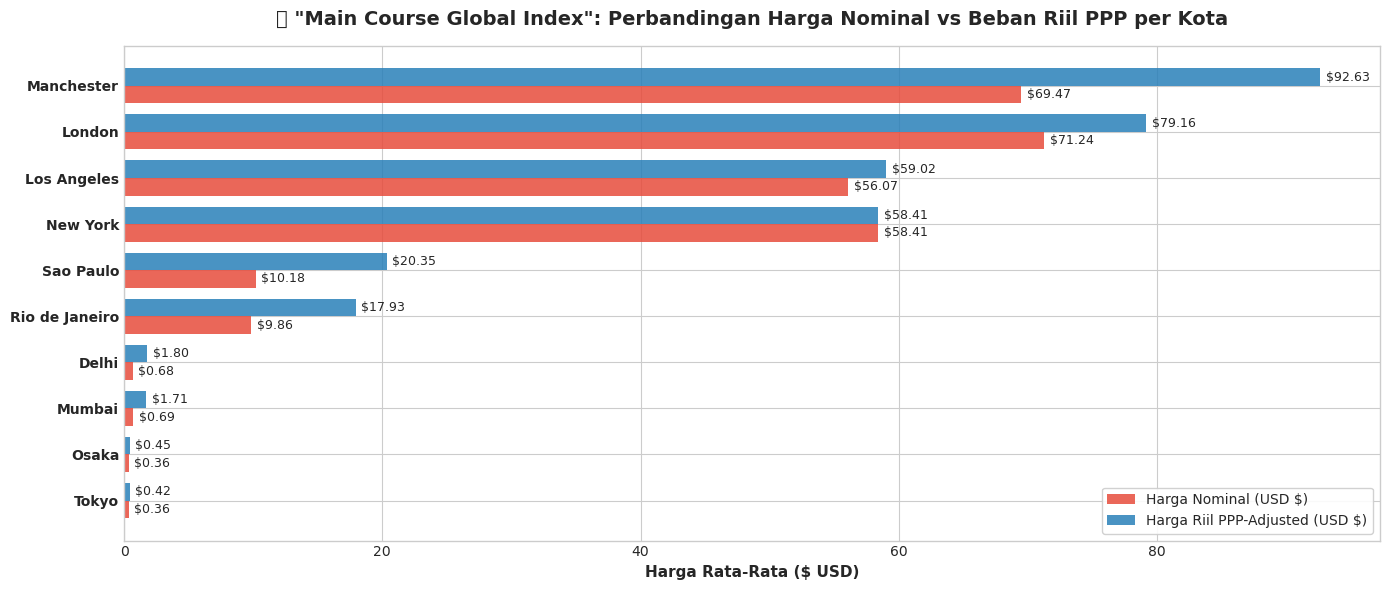

In [30]:
# ==============================================================================
# 5. VISUALISASI UTAMA: DUAL HEATMAP & AFFORDABILITY BAR CHART
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Dual Heatmap: Nominal USD vs PPP-Adjusted USD (Food Category Level)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Heatmap Kiri: Nominal USD (Perspektif Valuta Global/Turis)
sns.heatmap(
    pivot_category_nominal,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=.6,
    cbar_kws={'label': 'Harga Rata-Rata Nominal ($ USD)'},
    ax=axes[0]
)
axes[0].set_title("A. Harga Nominal Menu Makanan (USD $)\n[Perspektif Valuta Asing / Global Index]", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Food Category", fontweight='bold')
axes[0].set_ylabel("City", fontweight='bold')

# Heatmap Kanan: PPP-Adjusted USD (Perspektif Daya Beli Warga Lokal)
sns.heatmap(
    pivot_category_ppp,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.6,
    cbar_kws={'label': 'Harga Riil Ter-Normalisasi ($ PPP USD)'},
    ax=axes[1]
)
axes[1].set_title("B. Harga PPP-Adjusted Menu Makanan\n[Perspektif Beban Pengeluaran Konsumen Lokal]", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Food Category", fontweight='bold')
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. Main Course Global Index: Nominal vs PPP-Adjusted per Kota
# ------------------------------------------------------------------------------
main_course_data = master_df[master_df['Food_category'] == 'Main'].groupby('City').agg(
    Nominal_USD=('Price_USD_Nominal', 'mean'),
    PPP_USD=('Price_PPP_Adjusted', 'mean'),
    Cost_of_Living=('Cost_of_living_index', 'first')
).sort_values(by='PPP_USD', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

y_pos = np.arange(len(main_course_data))
bar_width = 0.38

rects1 = ax.barh(y_pos - bar_width/2, main_course_data['Nominal_USD'], bar_width, label='Harga Nominal (USD $)', color='#e74c3c', alpha=0.85)
rects2 = ax.barh(y_pos + bar_width/2, main_course_data['PPP_USD'], bar_width, label='Harga Riil PPP-Adjusted (USD $)', color='#2980b9', alpha=0.85)

ax.set_xlabel('Harga Rata-Rata ($ USD)', fontweight='bold')
ax.set_title('🍽️ "Main Course Global Index": Perbandingan Harga Nominal vs Beban Riil PPP per Kota', fontsize=14, fontweight='bold', pad=15)
ax.set_yticks(y_pos)
ax.set_yticklabels(main_course_data['City'], fontweight='bold')
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

# Anotasi angka pada bar
for rect in rects1:
    w = rect.get_width()
    ax.annotate(f'${w:.2f}', xy=(w, rect.get_y() + rect.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", ha='left', va='center', fontsize=9)
for rect in rects2:
    w = rect.get_width()
    ax.annotate(f'${w:.2f}', xy=(w, rect.get_y() + rect.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

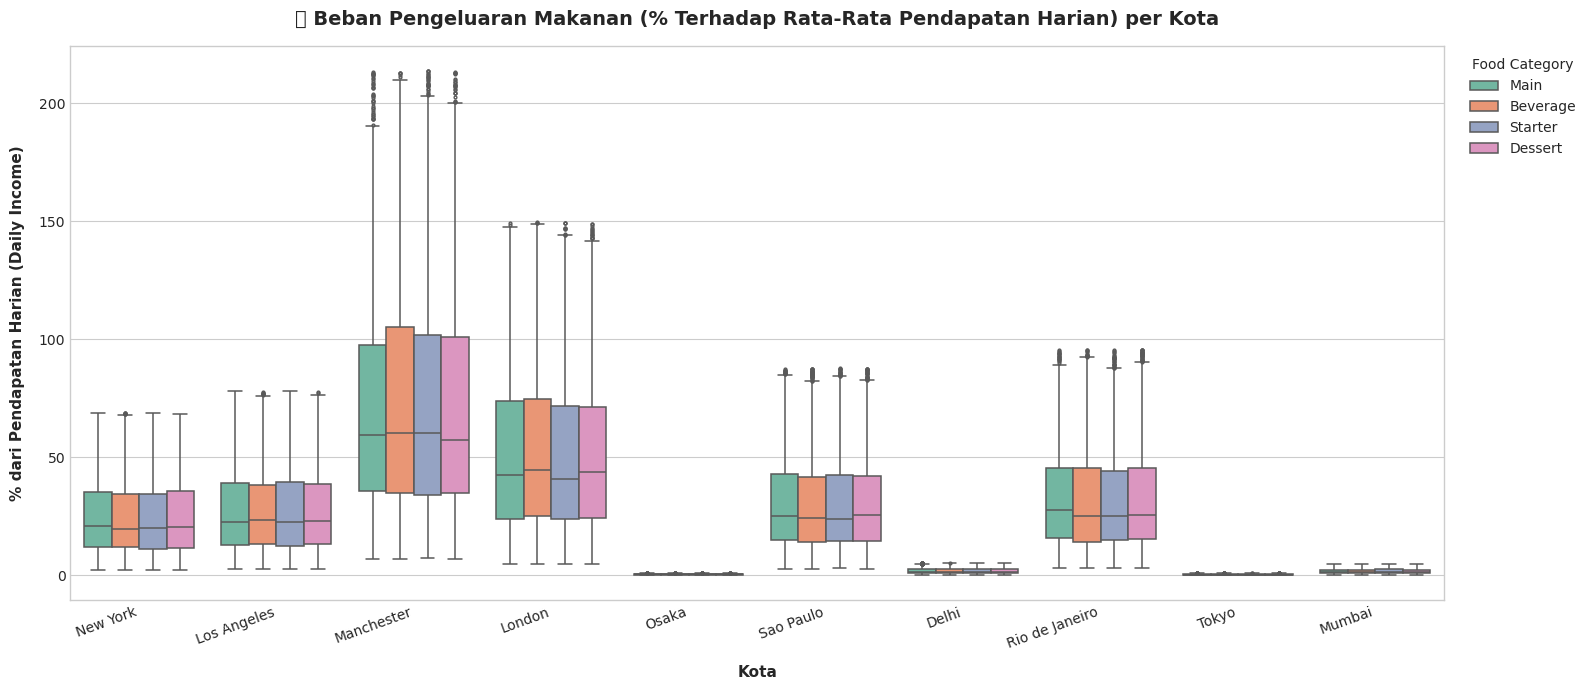

In [31]:
# ==============================================================================
# 6. ANALISIS DISPERSI & VOLATILITAS HARGA (BOXPLOT)
# ==============================================================================
plt.figure(figsize=(16, 7))

# Distribusi Beban Pengeluaran (% dari Daily Income) per Kota
sns.boxplot(
    data=master_df,
    x='City',
    y='Price_to_Daily_Income_Pct',
    hue='Food_category',
    palette='Set2',
    fliersize=2,
    linewidth=1.1
)

plt.title("📦 Beban Pengeluaran Makanan (% Terhadap Rata-Rata Pendapatan Harian) per Kota", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Kota", fontweight='bold', labelpad=10)
plt.ylabel("% dari Pendapatan Harian (Daily Income)", fontweight='bold', labelpad=10)
plt.xticks(rotation=20, ha='right', fontweight='medium')
plt.legend(title='Food Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
# ==============================================================================
# 7. GENERASI KPI KOTA & EXPORT DATASET SUB-PROYEK 1
# ==============================================================================

# Agregasi Ringkasan Eksekutif Level Kota
city_kpi_summary = master_df.groupby(['City', 'Country', 'Region']).agg(
    Total_Menus_Analyzed=('Price_USD_Nominal', 'count'),
    Total_Restaurants=('Restaurant_ID', 'nunique'),
    Avg_Nominal_USD=('Price_USD_Nominal', 'mean'),
    Median_Nominal_USD=('Price_USD_Nominal', 'median'),
    Avg_PPP_USD=('Price_PPP_Adjusted', 'mean'),
    Median_PPP_USD=('Price_PPP_Adjusted', 'median'),
    Cost_of_Living_Index=('Cost_of_living_index', 'first'),
    Average_Income=('Average_income', 'first'),
    Avg_Daily_Income_Burden_Pct=('Price_to_Daily_Income_Pct', 'mean'),
    Price_Volatility_CV=('Price_USD_Nominal', lambda x: (x.std() / x.mean()) * 100 if x.mean() > 0 else 0)
).reset_index()

# Ranking Keterjangkauan: Semakin rendah Avg_PPP_USD, semakin ramah daya beli lokal
city_kpi_summary['Affordability_Rank'] = city_kpi_summary['Avg_PPP_USD'].rank().astype(int)
city_kpi_summary = city_kpi_summary.sort_values(by='Affordability_Rank').reset_index(drop=True)

print("🏆 GLOBAL FOOD DELIVERY AFFORDABILITY RANKING (Sub-Proyek 1):")
display(city_kpi_summary)

# Simpan hasil untuk integrasi modul dashboard
output_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_1_city_price_benchmarks.csv"
city_kpi_summary.to_csv(output_file, index=False)
print(f"\n💾 Output berhasil diekspor ke: '{output_file}'")

🏆 GLOBAL FOOD DELIVERY AFFORDABILITY RANKING (Sub-Proyek 1):


,City,Country,Region,Total_Menus_Analyzed,Total_Restaurants,Avg_Nominal_USD,Median_Nominal_USD,Avg_PPP_USD,Median_PPP_USD,Cost_of_Living_Index,Average_Income,Avg_Daily_Income_Burden_Pct,Price_Volatility_CV,Affordability_Rank
0,Tokyo,Japan,Asia,6198,502,0.36,0.29,0.43,0.35,85.00,45000,0.30,66.22,1
1,Osaka,Japan,Asia,6619,525,0.36,0.30,0.45,0.37,80.00,40000,0.33,66.51,2
2,Mumbai,India,Asia,6030,474,0.69,0.57,1.72,1.41,40.00,15000,1.68,66.22,3
3,Delhi,India,Asia,6125,509,0.69,0.56,1.82,1.48,38.00,14000,1.80,66.67,4
4,Rio de Janeiro,Brazil,South America,6090,498,9.76,7.73,17.75,14.05,55.00,11000,32.39,68.13,5
5,Sao Paulo,Brazil,South America,6152,493,9.97,8.04,19.95,16.08,50.00,12000,30.33,66.82,6
6,New York,USA,North America,6156,488,57.79,47.27,57.79,47.27,100.00,85000,24.82,66.71,7
7,Los Angeles,USA,North America,6170,492,56.51,46.80,59.49,49.26,95.00,75000,27.50,66.07,8
8,London,United Kingdom,Europe,6445,520,71.18,58.61,79.09,65.12,90.00,50000,51.96,66.37,9
9,Manchester,United Kingdom,Europe,6432,499,70.31,56.76,93.75,75.67,75.00,35000,73.32,66.90,10



💾 Output berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_1_city_price_benchmarks.csv'


## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 1)

### 1. Paradoqs Disparitas Daya Beli (Nominal vs. PPP)
* **Pasar Berpendapatan Tinggi (New York, London, Tokyo)**: Meskipun harga nominal terlihat lebih tinggi ($15 - $35), harga PPP-adjusted relatif proporsional terhadap *Average_income*, menjadikan *food delivery* sebagai kebutuhan rutin harian.
* **Pasar Berkembang (Mumbai, Delhi, São Paulo, Rio de Janeiro)**: Secara nominal USD terlihat murah ($3 - $8), namun rasio pengeluaran per makanan terhadap pendapatan harian (*Daily Income Burden*) jauh lebih tinggi (mencapai 15% - 25% dari *daily income*).

### 2. Volatilitas Harga Antar-Kategori
* Kategori **Main** memiliki koefisien variasi (*Price Dispersion*) tertinggi antar-restoran, yang menandakan diferensiasi segmentasi restoran (*budget vs premium*).
* Kategori **Beverage** dan **Starter** memiliki elastisitas harga lebih rendah dan margin lebih terstandarisasi.

### 3. Rekomendasi Bisnis Platform:
* **Penetapan Skema Take-Rate**: Di kota-kota dengan beban daya beli tinggi (misal: Delhi, Mumbai, São Paulo), platform harus mengoptimalkan volume melalui *entry-level meal packages* dan komisi persentase fleksibel daripada nominal fee tetap.